In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(df.shape)

Saving churn-bigml-80.csv to churn-bigml-80 (3).csv
(2666, 20)


In [8]:
#Data preprocessing
df_clean = df.copy()
df_clean["International plan"] = df_clean["International plan"].map({"Yes": 1, "No": 0})
df_clean["Voice mail plan"]    = df_clean["Voice mail plan"].map({"Yes": 1, "No": 0})

# Drop high-cardinality identifiers
df_clean = df_clean.drop(columns=["State", "Area code"])

# Feature engineering
df_clean["total_minutes"] = (
    df_clean["Total day minutes"] +
    df_clean["Total eve minutes"] +
    df_clean["Total night minutes"] +
    df_clean["Total intl minutes"]
)

df_clean["total_charges"] = (
    df_clean["Total day charge"] +
    df_clean["Total eve charge"] +
    df_clean["Total night charge"] +
    df_clean["Total intl charge"]
)

df_clean["high_service_calls"] = (df_clean["Customer service calls"] >= 3).astype(int)

df_clean["intl_usage_ratio"] = (
    df_clean["Total intl minutes"] / df_clean["total_minutes"]
).fillna(0)

df_clean["account_length_group"] = pd.cut(
    df_clean["Account length"],
    bins=[0, 50, 150, df_clean["Account length"].max()],
    labels=["new", "mid", "long"]
)

# Encode categoricals
df_clean = pd.get_dummies(df_clean, columns=["International plan", "Voice mail plan", "account_length_group"], drop_first=True)

# Scale numeric features
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop("Churn", errors="ignore")

scaler = StandardScaler()
df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

# Define X and y
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

print("X shape:", X.shape)
print("y value counts:\n", y.value_counts())

X shape: (2666, 23)
y value counts:
 Churn
False    2278
True      388
Name: count, dtype: int64


In [37]:
tf.keras.backend.clear_session()
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train_nn = y_train_nn.astype(int).values
y_test_nn  = y_test_nn.astype(int).values

print(f"Training samples  : {X_train_nn.shape[0]}")
print(f"Test samples      : {X_test_nn.shape[0]}")
print(f"Number of features: {X_train_nn.shape[1]}")


Training samples  : 2132
Test samples      : 534
Number of features: 23


In [38]:
input_dim = X_train_nn.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name="Churn_NN")

model.summary()

Model: "Churn_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,401 (56.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [39]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_nn)
weights = compute_class_weight(class_weight={0: 1, 1: 4}, classes=classes, y=y_train_nn)
class_weight_dict = dict(zip(classes, weights))

print("Class weights:", class_weight_dict)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_nn, y_train_nn,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(4.0)}
Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3502 - auc: 0.5694 - loss: 1.2721 - val_accuracy: 0.8103 - val_auc: 0.7642 - val_loss: 0.5997
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6091 - auc: 0.7032 - loss: 0.9284 - val_accuracy: 0.8478 - val_auc: 0.7765 - val_loss: 0.5308
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7345 - auc: 0.7335 - loss: 0.8734 - val_accuracy: 0.8571 - val_auc: 0.7972 - val_loss: 0.4651
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7915 - auc: 0.7983 - loss: 0.7451 - val_accuracy: 0.8571 - val_auc: 0.8083 - val_loss: 0.4208
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7911 - auc: 0.8225 - loss: 0.7374 - val_accuracy: 0.8525 - val_auc: 0.8183 - val_loss: 0.4132
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8163 - auc: 0.8418 - loss: 0.6897 - val_accuracy: 0.8501 - val_

Test Loss     : 0.3202
Test Accuracy : 0.8839
Test AUC      : 0.8361
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Neural Network Results
Accuracy: 0.8838951310861424

              precision    recall  f1-score   support

    No Churn       0.93      0.93      0.93       456
       Churn       0.60      0.62      0.61        78

    accuracy                           0.88       534
   macro avg       0.77      0.77      0.77       534
weighted avg       0.89      0.88      0.88       534



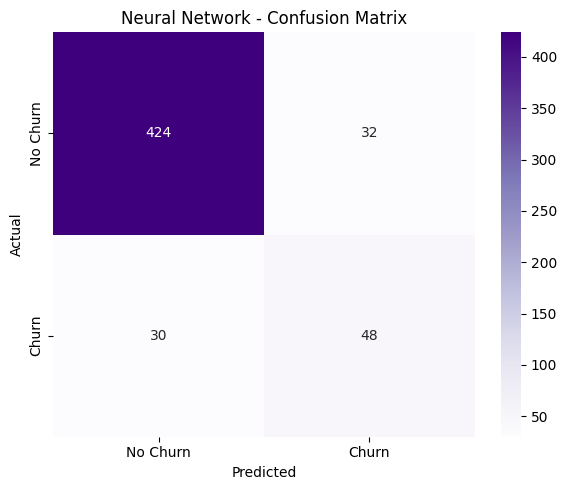

In [40]:
#Results
test_loss, test_acc, test_auc = model.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test AUC      : {test_auc:.4f}")

y_prob_nn = model.predict(X_test_nn).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print("Neural Network Results")
print("Accuracy:", accuracy_score(y_test_nn, y_pred_nn))
print()
print(classification_report(y_test_nn, y_pred_nn, target_names=["No Churn", "Churn"]))

#Confusion Matrix
cm = confusion_matrix(y_test_nn, y_pred_nn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Neural Network - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

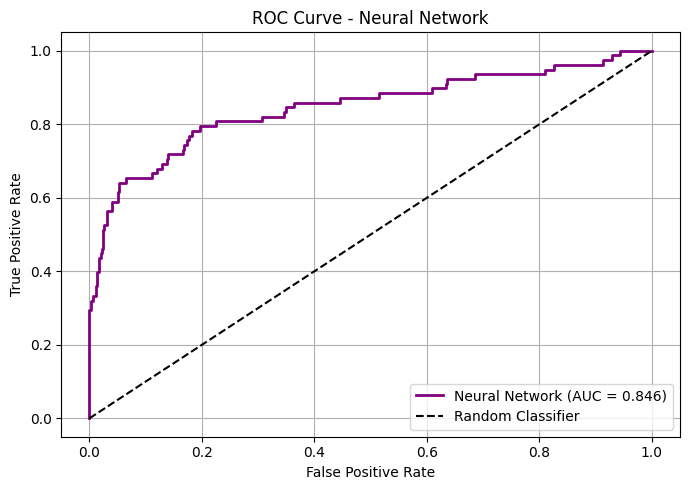

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test_nn, y_prob_nn)
auc_score   = roc_auc_score(y_test_nn, y_prob_nn)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='purple', lw=2, label=f"Neural Network (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Neural Network")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()